## Time-series Forecasting Using Facebook Prophet Package

Forecasting is a technique that is used for a variety of different purposes and situations such as sales forecasting, operational and budget planning etc. Similarly there are a variety of different techniques such as moving averages, smoothening, ARIMA etc to statistically make a forecast.

In [4]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# Import necessary libraries for data manipulation, visualization, and time series forecasting
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Import Holt-Winters model for exponential smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Import ARIMA model for AutoRegressive Integrated Moving Average
from statsmodels.tsa.arima.model import ARIMA
# Import Prophet model for forecasting, developed by Facebook
from prophet import Prophet
# -----------------------------
# Load the dataset and preprocess it
# -----------------------------
# Load the 'flights' dataset from seaborn examples
flights = sns.load_dataset('flights')


In [21]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


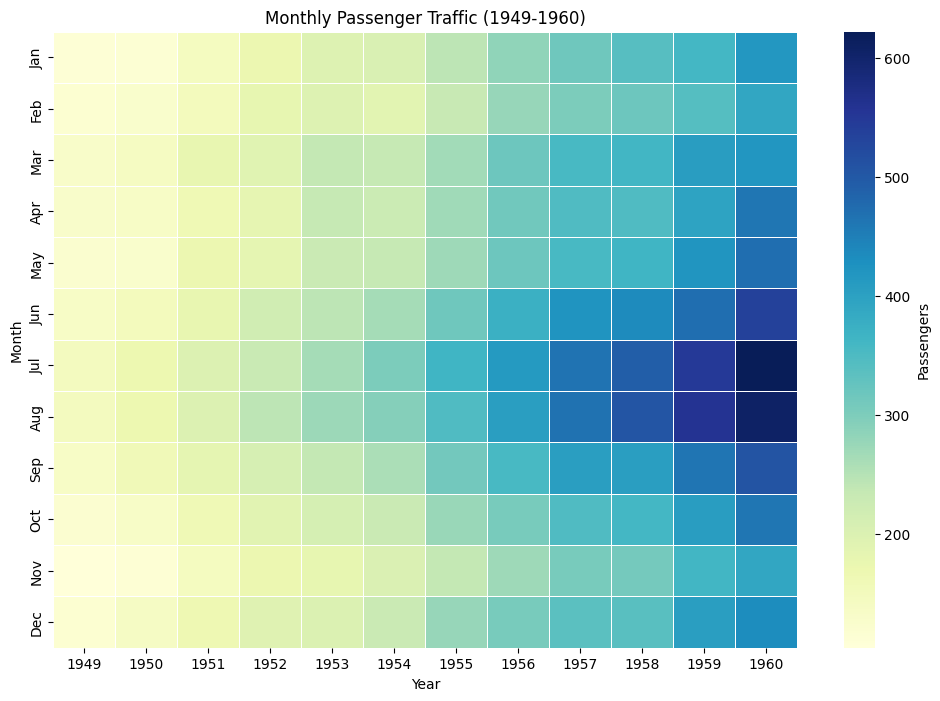

In [26]:
# Convert 'month' and 'year' columns into a single datetime column 'ds' (Date Stamp)
flights['month'] = pd.to_datetime(flights['month'].astype(str) + flights['year'].astype(str), format='%b%Y')
# Select and rename columns to 'ds' and 'y' as required by Prophet and common in time series analysis
flights = flights[['month', 'passengers']].rename(columns={'month':'ds','passengers':'y'})
# Set the 'ds' column as the DataFrame index
flights.set_index('ds', inplace=True)
# Explicitly set the frequency of the time series to 'Month Start' to avoid warnings and ensure consistency
flights = flights.asfreq('MS')
# Reset index to access 'ds' as a column and extract year and month
flights_heatmap_data = flights.reset_index().copy()
flights_heatmap_data['year'] = flights_heatmap_data['ds'].dt.year
flights_heatmap_data['month'] = flights_heatmap_data['ds'].dt.strftime('%b') # Month abbreviation
# Create a pivot table for the heatmap: months on y-axis, years on x-axis
heatmap_data = flights_heatmap_data.pivot_table(index='month', columns='year', values='y')
# Define the order of months for correct plotting
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data = heatmap_data.reindex(month_order)
# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', fmt=".0f", linewidths=.5, cbar_kws={'label': 'Passengers'})
plt.title('Monthly Passenger Traffic (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

C:\Users\shash\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:44:00 - cmdstanpy - INFO - Chain [1] start processing
12:44:00 - cmdstanpy - INFO - Chain [1] done processing


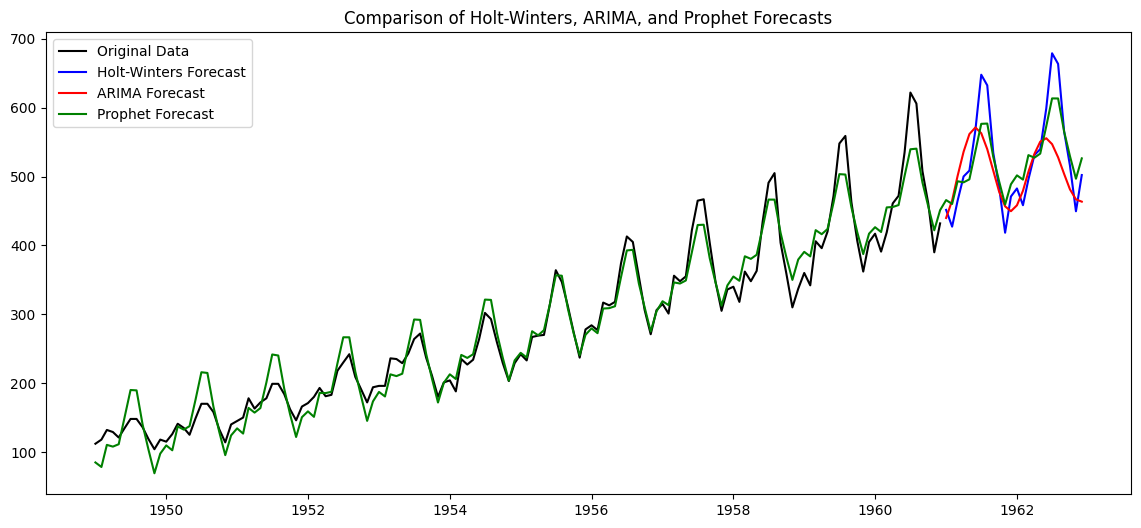

In [27]:
# -----------------------------
# Holt-Winters Model: Initial Training and Forecasting
# -----------------------------
# Initialize Holt-Winters Exponential Smoothing model with additive trend and seasonal components
# Seasonal period is set to 12 as the data is monthly and shows yearly seasonality
hw_model = ExponentialSmoothing(flights['y'], trend='add', seasonal='add', seasonal_periods=12)
# Fit the Holt-Winters model to the entire dataset
hw_fit = hw_model.fit()
# Forecast the next 24 periods (2 years) using the fitted model
hw_forecast = hw_fit.forecast(24)
# -----------------------------
# ARIMA Model: Initial Training and Forecasting
# -----------------------------
# Initialize ARIMA model with an order of (2,1,2). These parameters (p,d,q) are chosen arbitrarily here
# but would typically be determined through auto_arima or ACF/PACF analysis.
arima_model = ARIMA(flights['y'], order=(2,1,2))
# Fit the ARIMA model to the entire dataset
arima_fit = arima_model.fit()
# Forecast the next 24 periods (2 years) using the fitted model
arima_forecast = arima_fit.forecast(24)
# -----------------------------
# Prophet Model: Initial Training and Forecasting
# -----------------------------
# Reset index and rename columns to 'ds' and 'y', as Prophet expects these specific column names
prophet_df = flights.reset_index()
# Initialize Prophet model, enabling yearly seasonality
prophet_model = Prophet(yearly_seasonality=True)
# Fit the Prophet model to the entire dataset
prophet_model.fit(prophet_df)
# Create a future DataFrame for forecasting, specifying 24 periods with 'Month Start' frequency
future = prophet_model.make_future_dataframe(periods=24, freq='MS')
# Generate forecasts using the fitted Prophet model
prophet_forecast = prophet_model.predict(future)
# -----------------------------
# Plotting: Comparison of Initial Forecasts
# -----------------------------
# Set the figure size for better visualization
plt.figure(figsize=(14,6))
# Plot the original 'flights' data
plt.plot(flights.index, flights['y'], label='Original Data', color='black')
# Plot the Holt-Winters forecast
plt.plot(hw_forecast.index, hw_forecast, label='Holt-Winters Forecast', color='blue')
# Plot the ARIMA forecast
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast', color='red')
# Plot the Prophet forecast. 'yhat' is the predicted value from Prophet
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast', color='green')
# Add title and legend for clarity
plt.title("Comparison of Holt-Winters, ARIMA, and Prophet Forecasts")
plt.legend()
# Display the plot
plt.show()

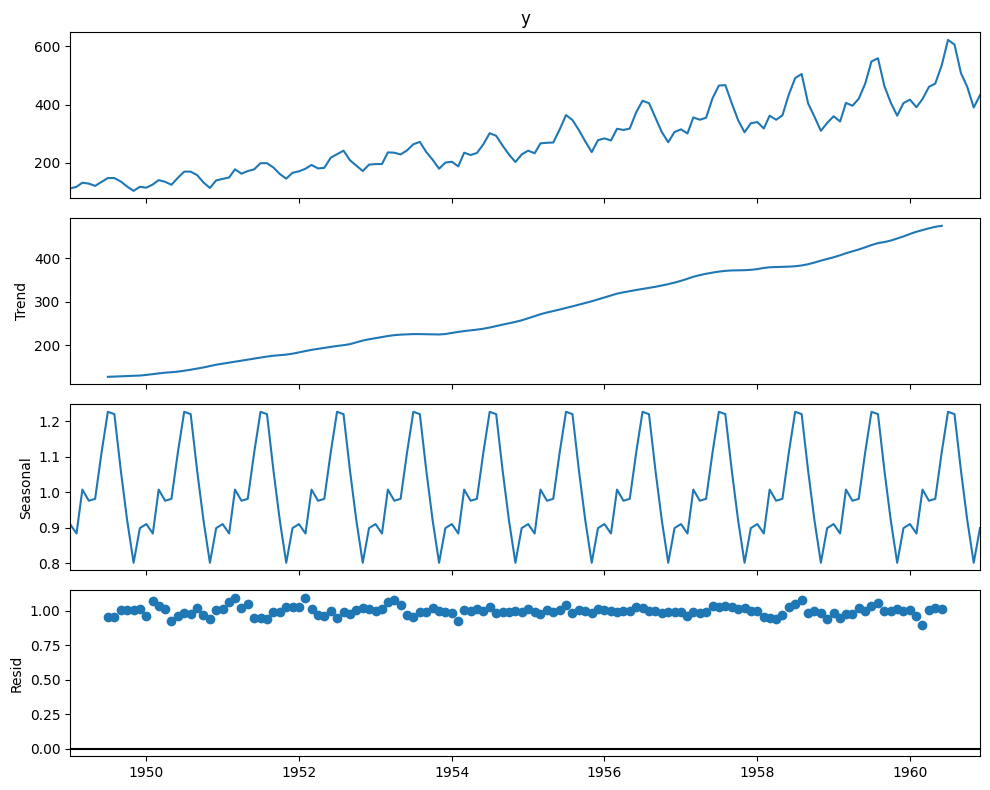

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Perform additive decomposition as the seasonal fluctuations seem to be consistent over time.
# The period is set to 12 for yearly seasonality in monthly data.
decomposition = seasonal_decompose(flights['y'], model='multiplicative', period=12)
# Plot the decomposed components (Original, Trend, Seasonal, Residual)
fig = decomposition.plot()
# Set a good figure size for the plot
fig.set_size_inches(10, 8)
# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Display the plot
plt.show()

In [8]:
from sklearn.metrics import mean_absolute_error
# --- Holt-Winters MAE Calculation (In-Sample) ---
# Calculate MAE for Holt-Winters using the fitted values against the original data
hw_mae = mean_absolute_error(flights['y'], hw_fit.fittedvalues)
print(f"Holt-Winters MAE: {hw_mae:.2f}")
# --- ARIMA MAE Calculation (In-Sample) ---
# Calculate MAE for ARIMA using the fitted values against the original data
arima_mae = mean_absolute_error(flights['y'], arima_fit.fittedvalues)
print(f"ARIMA MAE: {arima_mae:.2f}")
# --- Prophet MAE Calculation (In-Sample) ---
# Prophet's predict method on the original dataframe gives in-sample predictions. 
# We use 'yhat' from the predictions DataFrame for MAE calculation.
prophet_predictions = prophet_model.predict(prophet_df)
prophet_mae = mean_absolute_error(prophet_df['y'], prophet_predictions['yhat'])
print(f"Prophet MAE: {prophet_mae:.2f}")

Holt-Winters MAE: 9.41
ARIMA MAE: 20.85
Prophet MAE: 17.38


Training data points: 132
Test data points: 12


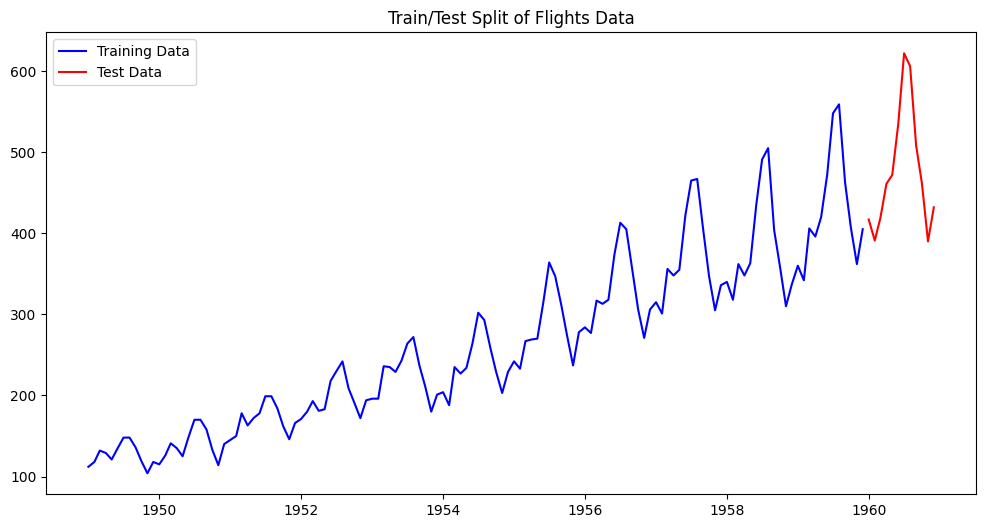

In [9]:
# Define the split point for training and testing data. Using '1960-01-01' to reserve the last 12 months for testing.
split_point = '1960-01-01'
# Create the training set: all data before the split_point
train = flights.loc[flights.index < split_point]
# Create the test set: all data from the split_point onwards
test = flights.loc[flights.index >= split_point]
# Print the number of data points in training and test sets for verification
print(f"Training data points: {len(train)}")
print(f"Test data points: {len(test)}")
# Visualize the train/test split to ensure correctness
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['y'], label='Training Data', color='blue')
plt.plot(test.index, test['y'], label='Test Data', color='red')
plt.title('Train/Test Split of Flights Data')
plt.legend()
plt.show()

Holt-Winters MAE on Test Set: 13.38


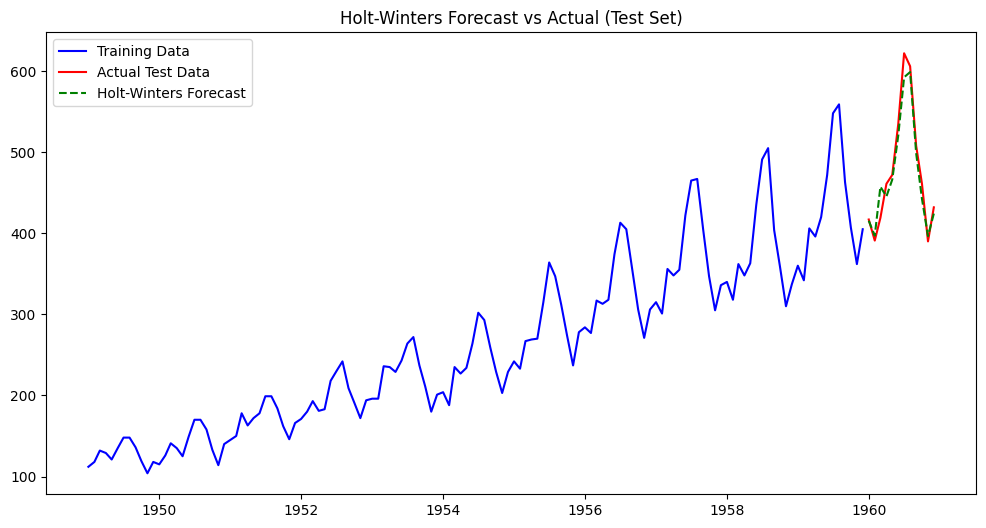

In [10]:
# Retrain Holt-Winters model specifically on the training data
hw_model_train = ExponentialSmoothing(train['y'], trend='add', seasonal='add', seasonal_periods=12)
hw_fit_train = hw_model_train.fit()
# Forecast for the length of the test period using the retrained model
hw_forecast_test = hw_fit_train.forecast(len(test))
# Calculate Mean Absolute Error (MAE) comparing the forecast with the actual test data
hw_mae_test = mean_absolute_error(test['y'], hw_forecast_test)
print(f"Holt-Winters MAE on Test Set: {hw_mae_test:.2f}")
# Plot the training data, actual test data, and the Holt-Winters forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['y'], label='Training Data', color='blue')
plt.plot(test.index, test['y'], label='Actual Test Data', color='red')
plt.plot(hw_forecast_test.index, hw_forecast_test, label='Holt-Winters Forecast', color='green', linestyle='--')
plt.title('Holt-Winters Forecast vs Actual (Test Set)')
plt.legend()
plt.show()

ARIMA MAE on Test Set: 41.83


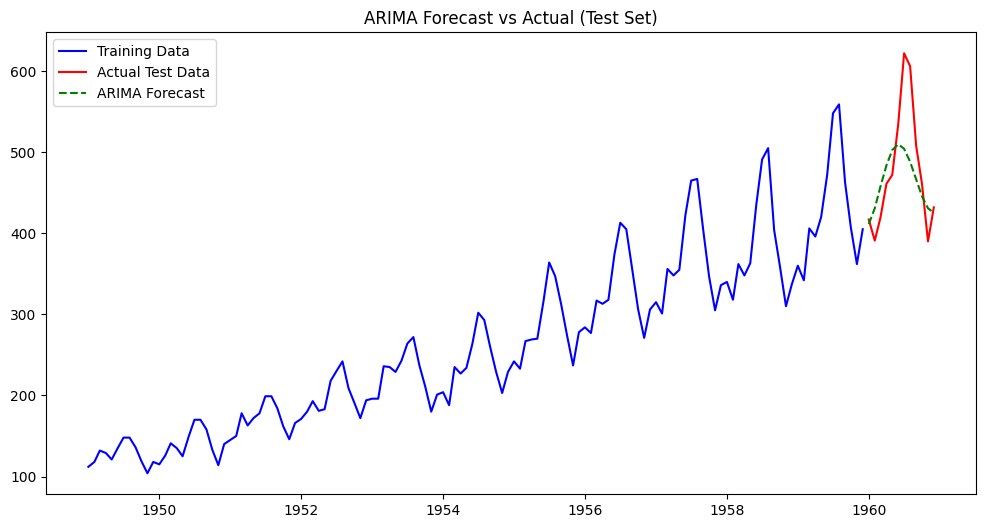

In [11]:
# Retrain ARIMA model on the training data. Using the same (p,d,q) order as before.
arima_model_train = ARIMA(train['y'], order=(2,1,2))
arima_fit_train = arima_model_train.fit()
# Forecast for the length of the test period using the retrained model
arima_forecast_test = arima_fit_train.forecast(len(test))
# Calculate Mean Absolute Error (MAE) comparing the forecast with the actual test data
arima_mae_test = mean_absolute_error(test['y'], arima_forecast_test)
print(f"ARIMA MAE on Test Set: {arima_mae_test:.2f}")
# Plot the training data, actual test data, and the ARIMA forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['y'], label='Training Data', color='blue')
plt.plot(test.index, test['y'], label='Actual Test Data', color='red')
plt.plot(arima_forecast_test.index, arima_forecast_test, label='ARIMA Forecast', color='green', linestyle='--')
plt.title('ARIMA Forecast vs Actual (Test Set)')
plt.legend()
plt.show()

12:33:47 - cmdstanpy - INFO - Chain [1] start processing
12:33:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE on Test Set: 33.44


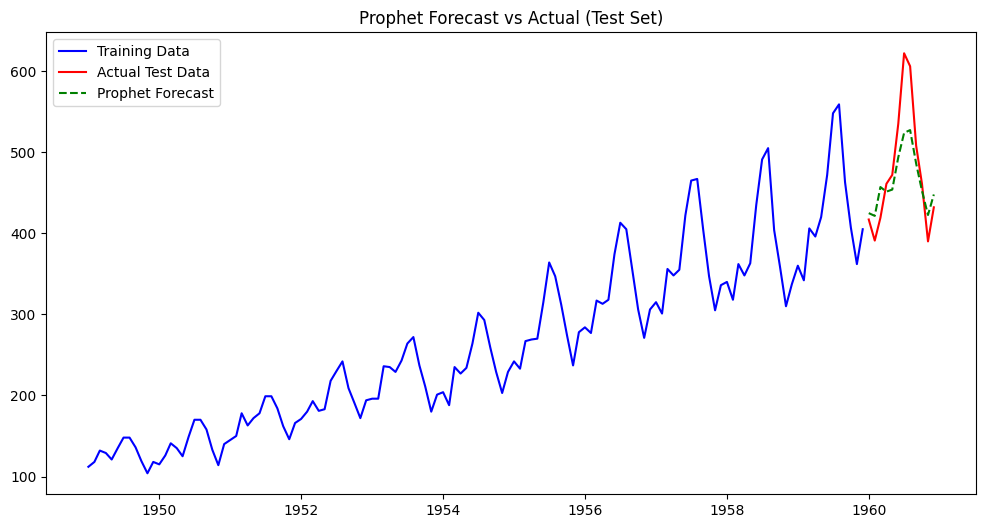

In [12]:
# Prophet requires a DataFrame with 'ds' and 'y' columns. Prepare training and testing DataFrames accordingly.
prophet_train_df = train.reset_index().rename(columns={'ds':'ds', 'y':'y'})
prophet_test_df = test.reset_index().rename(columns={'ds':'ds', 'y':'y'})
# Retrain Prophet model on the training data, enabling yearly seasonality
prophet_model_train = Prophet(yearly_seasonality=True)
prophet_model_train.fit(prophet_train_df)
# Create a future DataFrame specifically for the test period to generate forecasts
future_prophet_test = prophet_model_train.make_future_dataframe(periods=len(test), freq='MS', include_history=False)
# Generate forecasts for the test period using the retrained Prophet model
prophet_forecast_test = prophet_model_train.predict(future_prophet_test)
# Calculate Mean Absolute Error (MAE) comparing Prophet's 'yhat' (prediction) with the actual test data
prophet_mae_test = mean_absolute_error(prophet_test_df['y'], prophet_forecast_test['yhat'])
print(f"Prophet MAE on Test Set: {prophet_mae_test:.2f}")
# Plot the training data, actual test data, and the Prophet forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['y'], label='Training Data', color='blue')
plt.plot(test.index, test['y'], label='Actual Test Data', color='red')
plt.plot(prophet_forecast_test['ds'], prophet_forecast_test['yhat'], label='Prophet Forecast', color='green', linestyle='--')
plt.title('Prophet Forecast vs Actual (Test Set)')
plt.legend()
plt.show()

In [13]:
# Print the calculated MAE for each model on the test set for easy comparison
print(f"Holt-Winters MAE on Test Set: {hw_mae_test:.2f}")
print(f"ARIMA MAE on Test Set: {arima_mae_test:.2f}")
print(f"Prophet MAE on Test Set: {prophet_mae_test:.2f}")

Holt-Winters MAE on Test Set: 13.38
ARIMA MAE on Test Set: 41.83
Prophet MAE on Test Set: 33.44
